In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/chaahatsingal/castudythermal/CA1/CA1.txt
/kaggle/input/datasets/chaahatsingal/castudythermal/CA5/CA5.txt
/kaggle/input/datasets/chaahatsingal/castudythermal/CA2/CA2.txt
/kaggle/input/datasets/chaahatsingal/castudythermal/CA4/CA4.txt
/kaggle/input/datasets/chaahatsingal/castudythermal/CA3/CA3.txt


In [5]:
import pandas as pd

file_path = "/kaggle/input/datasets/chaahatsingal/castudythermal/CA1/CA1.txt"

df = pd.read_csv(file_path, delim_whitespace=True)
df.head()

/tmp/ipykernel_55/3253655225.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)


,time,V(chg_limit_f),V(dtdt_f),V(nodea),V(qgen),V(qirr),V(qrev),V(qrxn),V(r0eff),V(runaway_precursor),V(soc),V(tcell_abs),V(th_dcore),V(th_dsurf),V(th_tcoreabs),V(th_tdelta),V(th_tsurfabs),V(therm_shdn_f),I(RShunt)
0,0.000000e+00,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.000,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.00000
1,1.000000e-11,0.0,7.413370e-12,2.366587,0.370669,0.639004,-0.268336,0.0,0.051,0.0,0.8,25.0,7.413371e-14,7.413371e-26,25.0,7.413371e-14,25.0,0.0,3.00001
2,1.007802e-11,0.0,7.471211e-12,2.366587,0.370669,0.639004,-0.268336,0.0,0.051,0.0,0.8,25.0,7.471211e-14,7.471662e-26,25.0,7.471211e-14,25.0,0.0,3.00001
3,1.023407e-11,0.0,7.586892e-12,2.366587,0.370669,0.639004,-0.268336,0.0,0.051,0.0,0.8,25.0,7.586892e-14,7.589149e-26,25.0,7.586892e-14,25.0,0.0,3.00001
4,1.054615e-11,0.0,7.818254e-12,2.366587,0.370669,0.639004,-0.268336,0.0,0.051,0.0,0.8,25.0,7.818254e-14,7.829536e-26,25.0,7.818254e-14,25.0,0.0,3.00001


In [6]:
df.columns = df.columns.str.replace('V\\(|\\)', '', regex=True)
df.columns = df.columns.str.replace('I\\(|\\)', '', regex=True)

print(df.columns)

Index(['time', 'chg_limit_f', 'dtdt_f', 'nodea', 'qgen', 'qirr', 'qrev',
       'qrxn', 'r0eff', 'runaway_precursor', 'soc', 'tcell_abs', 'th_dcore',
       'th_dsurf', 'th_tcoreabs', 'th_tdelta', 'th_tsurfabs', 'therm_shdn_f',
       'RShunt'],
      dtype='object')


In [11]:
T = df['tcell_abs'] if 'tcell_abs' in df.columns else None
I = df['Rshunt'] if 'rshunt' in df.columns else None
dTdt = df['dtdt_f']

Qirr = df['qirr']
Qrev = df['qrev']
Qrxn = df['qrxn']
R0 = df['r0eff']

In [12]:
print(Qirr.head())
print(Qrev.head())
print(Qrxn.head())

0    0.000000
1    0.639004
2    0.639004
3    0.639004
4    0.639004
Name: qirr, dtype: float64
0    0.000000
1   -0.268336
2   -0.268336
3   -0.268336
4   -0.268336
Name: qrev, dtype: float64
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: qrxn, dtype: float64


In [16]:
df_ds = df.iloc[::100].copy()
df_ds = df_ds[df_ds["time"] > 0.01].reset_index(drop=True)

X shape: (17053, 3)
y shape: (17053,)
Final estimated parameters:
[[ 0.000545  ]
 [ 0.02138579]
 [-0.02001662]]
RMSE: 1.0447848174679015e-07
MAE: 7.838145566108187e-08


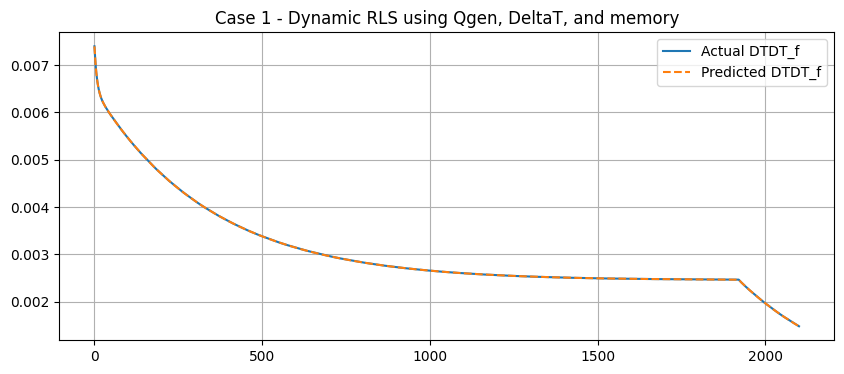

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# downsampled data already in df_ds

y = df_ds['dtdt_f'].values
Qgen = df_ds['qgen'].values
DeltaT = df_ds['th_tdelta'].values

y_prev = np.roll(y, 1)
y_prev[0] = y[0]

# scale each term
Qgen_n = Qgen / np.max(np.abs(Qgen)) if np.max(np.abs(Qgen)) != 0 else Qgen
DeltaT_n = DeltaT / np.max(np.abs(DeltaT)) if np.max(np.abs(DeltaT)) != 0 else DeltaT
y_prev_n = y_prev / np.max(np.abs(y_prev)) if np.max(np.abs(y_prev)) != 0 else y_prev

X = np.vstack([
    y_prev_n,
    Qgen_n,
    DeltaT_n
]).T

print("X shape:", X.shape)
print("y shape:", y.shape)

# RLS
n = X.shape[1]
theta = np.zeros((n, 1))
P = np.eye(n) * 100
lam = 0.995
theta_history = []

for i in range(len(y)):
    x_i = X[i].reshape(-1, 1)
    y_i = y[i]

    denom = lam + (x_i.T @ P @ x_i)[0, 0]
    if abs(denom) < 1e-12:
        continue

    K = (P @ x_i) / denom
    err = y_i - (x_i.T @ theta)[0, 0]
    theta = theta + K * err
    P = (P - K @ x_i.T @ P) / lam
    P = 0.5 * (P + P.T)

    theta_history.append(theta.flatten())

theta_history = np.array(theta_history)

print("Final estimated parameters:")
print(theta)

y_pred = (X @ theta).flatten()

rmse = np.sqrt(np.mean((y - y_pred)**2))
mae = np.mean(np.abs(y - y_pred))

print("RMSE:", rmse)
print("MAE:", mae)

plt.figure(figsize=(10,4))
plt.plot(df_ds['time'], y, label="Actual DTDT_f")
plt.plot(df_ds['time'], y_pred, '--', label="Predicted DTDT_f")
plt.legend()
plt.title("Case 1 - Dynamic RLS using Qgen, DeltaT, and memory")
plt.grid(True)
plt.show()

Index(['time', 'chg_limit_f', 'dtdt_f', 'nodea', 'qgen', 'qirr', 'qrev',
       'qrxn', 'r0eff', 'runaway_precursor', 'soc', 'tcell_abs', 'th_dcore',
       'th_dsurf', 'th_tcoreabs', 'th_tdelta', 'th_tsurfabs', 'therm_shdn_f',
       'RShunt'],
      dtype='object')
Rows before: 1716580
Rows after: 17164
X shape: (17164, 3)
y shape: (17164,)
Case 2 final estimated parameters:
[[ 0.00183644]
 [ 0.03045392]
 [-0.02582026]]
Case 2 RMSE: 2.0015271642863653e-05
Case 2 MAE: 1.731754003674914e-05


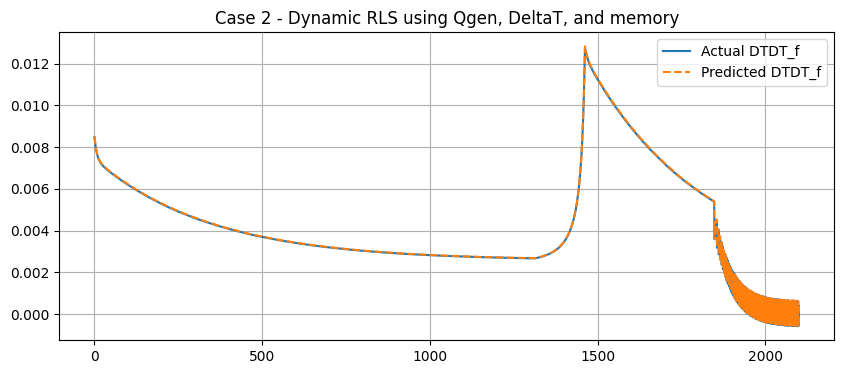

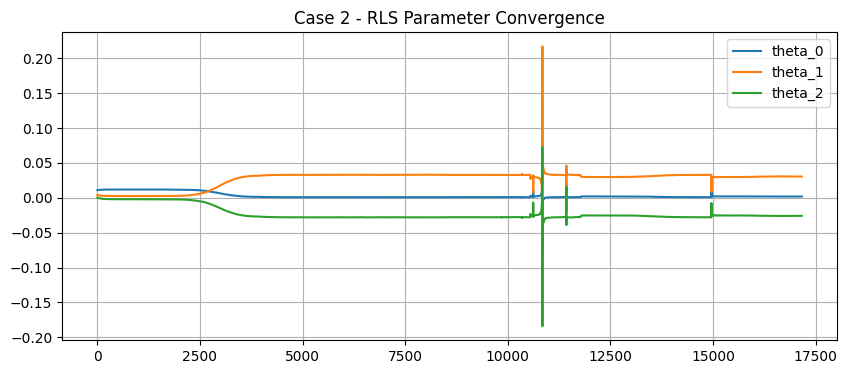

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load Case 2 data
# -------------------------------
file_path = "/kaggle/input/datasets/chaahatsingal/castudythermal/CA2/CA2.txt"
df = pd.read_csv(file_path, sep=r"\s+")

# -------------------------------
# 2. Clean column names
# -------------------------------
df.columns = df.columns.str.replace(r'V\(|\)', '', regex=True)
df.columns = df.columns.str.replace(r'I\(|\)', '', regex=True)

print(df.columns)

# -------------------------------
# 3. Downsample + remove initial transient
# -------------------------------
df_ds = df.iloc[::100].copy()
df_ds = df_ds[df_ds["time"] > 0.01].reset_index(drop=True)

print("Rows before:", len(df))
print("Rows after:", len(df_ds))

# -------------------------------
# 4. Extract signals
# -------------------------------
y = df_ds["dtdt_f"].values
Qgen = df_ds["qgen"].values
DeltaT = df_ds["th_tdelta"].values

# previous output = memory term
y_prev = np.roll(y, 1)
y_prev[0] = y[0]

# -------------------------------
# 5. Normalize each term safely
# -------------------------------
Qgen_n = Qgen / np.max(np.abs(Qgen)) if np.max(np.abs(Qgen)) != 0 else Qgen
DeltaT_n = DeltaT / np.max(np.abs(DeltaT)) if np.max(np.abs(DeltaT)) != 0 else DeltaT
y_prev_n = y_prev / np.max(np.abs(y_prev)) if np.max(np.abs(y_prev)) != 0 else y_prev

# -------------------------------
# 6. Build dynamic input matrix
# -------------------------------
X = np.vstack([
    y_prev_n,
    Qgen_n,
    DeltaT_n
]).T

print("X shape:", X.shape)
print("y shape:", y.shape)

# -------------------------------
# 7. RLS initialization
# -------------------------------
n = X.shape[1]
theta = np.zeros((n, 1))
P = np.eye(n) * 100
lam = 0.995
theta_history = []

# -------------------------------
# 8. RLS loop
# -------------------------------
for i in range(len(y)):
    x_i = X[i].reshape(-1, 1)
    y_i = y[i]

    denom = lam + (x_i.T @ P @ x_i)[0, 0]
    if abs(denom) < 1e-12:
        continue

    K = (P @ x_i) / denom
    err = y_i - (x_i.T @ theta)[0, 0]
    theta = theta + K * err
    P = (P - K @ x_i.T @ P) / lam
    P = 0.5 * (P + P.T)

    theta_history.append(theta.flatten())

theta_history = np.array(theta_history)

print("Case 2 final estimated parameters:")
print(theta)

# -------------------------------
# 9. Prediction
# -------------------------------
y_pred = (X @ theta).flatten()

# -------------------------------
# 10. Error metrics
# -------------------------------
rmse = np.sqrt(np.mean((y - y_pred)**2))
mae = np.mean(np.abs(y - y_pred))

print("Case 2 RMSE:", rmse)
print("Case 2 MAE:", mae)

# -------------------------------
# 11. Plot actual vs predicted
# -------------------------------
plt.figure(figsize=(10,4))
plt.plot(df_ds["time"], y, label="Actual DTDT_f")
plt.plot(df_ds["time"], y_pred, "--", label="Predicted DTDT_f")
plt.legend()
plt.title("Case 2 - Dynamic RLS using Qgen, DeltaT, and memory")
plt.grid(True)
plt.show()

# -------------------------------
# 12. Plot parameter convergence
# -------------------------------
plt.figure(figsize=(10,4))
for i in range(theta_history.shape[1]):
    plt.plot(theta_history[:, i], label=f"theta_{i}")
plt.legend()
plt.title("Case 2 - RLS Parameter Convergence")
plt.grid(True)
plt.show()

Index(['time', 'chg_limit_f', 'dtdt_f', 'nodea', 'qgen', 'qirr', 'qrev',
       'qrxn', 'r0eff', 'runaway_precursor', 'soc', 'tcell_abs', 'th_dcore',
       'th_dsurf', 'th_tcoreabs', 'th_tdelta', 'th_tsurfabs', 'therm_shdn_f',
       'RShunt'],
      dtype='object')
Rows before: 1712432
Rows after: 17123
X shape: (17123, 3)
y shape: (17123,)
Case 4 final estimated parameters:
[[ 0.00121184]
 [ 0.03154181]
 [-0.03002234]]
Case 4 RMSE: 1.8733972752772082e-07
Case 4 MAE: 9.92850679088905e-08


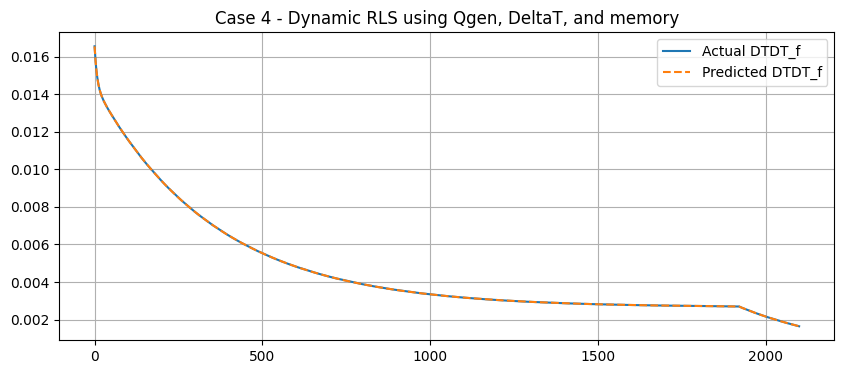

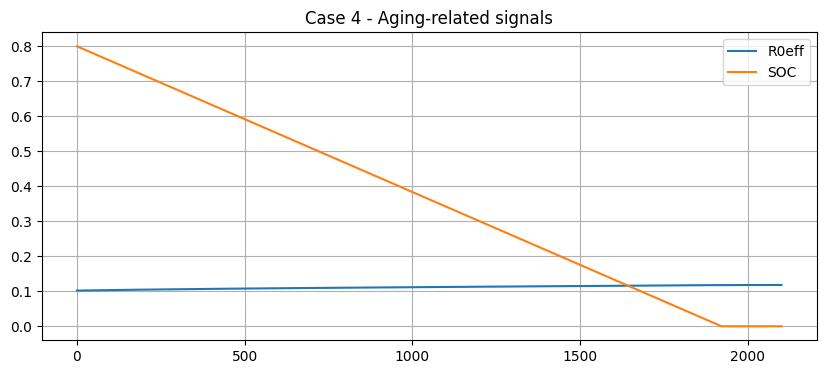

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load Case 4 data
# -------------------------------
file_path = "/kaggle/input/datasets/chaahatsingal/castudythermal/CA4/CA4.txt"
df = pd.read_csv(file_path, sep=r"\s+")

# -------------------------------
# 2. Clean column names
# -------------------------------
df.columns = df.columns.str.replace(r'V\(|\)', '', regex=True)
df.columns = df.columns.str.replace(r'I\(|\)', '', regex=True)

print(df.columns)

# -------------------------------
# 3. Downsample + remove initial transient
# -------------------------------
df_ds = df.iloc[::100].copy()
df_ds = df_ds[df_ds["time"] > 0.01].reset_index(drop=True)

print("Rows before:", len(df))
print("Rows after:", len(df_ds))

# -------------------------------
# 4. Extract signals
# -------------------------------
y = df_ds["dtdt_f"].values
Qgen = df_ds["qgen"].values
DeltaT = df_ds["th_tdelta"].values
R0eff = df_ds["r0eff"].values
SOC = df_ds["soc"].values

# previous output = memory term
y_prev = np.roll(y, 1)
y_prev[0] = y[0]

# -------------------------------
# 5. Normalize each term safely
# -------------------------------
Qgen_n = Qgen / np.max(np.abs(Qgen)) if np.max(np.abs(Qgen)) != 0 else Qgen
DeltaT_n = DeltaT / np.max(np.abs(DeltaT)) if np.max(np.abs(DeltaT)) != 0 else DeltaT
y_prev_n = y_prev / np.max(np.abs(y_prev)) if np.max(np.abs(y_prev)) != 0 else y_prev

# -------------------------------
# 6. Build dynamic input matrix
# -------------------------------
X = np.vstack([
    y_prev_n,
    Qgen_n,
    DeltaT_n
]).T

print("X shape:", X.shape)
print("y shape:", y.shape)

# -------------------------------
# 7. RLS initialization
# -------------------------------
n = X.shape[1]
theta = np.zeros((n, 1))
P = np.eye(n) * 100
lam = 0.995
theta_history = []

# -------------------------------
# 8. RLS loop
# -------------------------------
for i in range(len(y)):
    x_i = X[i].reshape(-1, 1)
    y_i = y[i]

    denom = lam + (x_i.T @ P @ x_i)[0, 0]
    if abs(denom) < 1e-12:
        continue

    K = (P @ x_i) / denom
    err = y_i - (x_i.T @ theta)[0, 0]
    theta = theta + K * err
    P = (P - K @ x_i.T @ P) / lam
    P = 0.5 * (P + P.T)

    theta_history.append(theta.flatten())

theta_history = np.array(theta_history)

print("Case 4 final estimated parameters:")
print(theta)

# -------------------------------
# 9. Prediction
# -------------------------------
y_pred = (X @ theta).flatten()

# -------------------------------
# 10. Error metrics
# -------------------------------
rmse = np.sqrt(np.mean((y - y_pred)**2))
mae = np.mean(np.abs(y - y_pred))

print("Case 4 RMSE:", rmse)
print("Case 4 MAE:", mae)

# -------------------------------
# 11. Plot actual vs predicted
# -------------------------------
plt.figure(figsize=(10,4))
plt.plot(df_ds["time"], y, label="Actual DTDT_f")
plt.plot(df_ds["time"], y_pred, "--", label="Predicted DTDT_f")
plt.legend()
plt.title("Case 4 - Dynamic RLS using Qgen, DeltaT, and memory")
plt.grid(True)
plt.show()

# -------------------------------
# 12. Plot R0eff and SOC (aging insight)
# -------------------------------
plt.figure(figsize=(10,4))
plt.plot(df_ds["time"], R0eff, label="R0eff")
plt.plot(df_ds["time"], SOC, label="SOC")
plt.legend()
plt.title("Case 4 - Aging-related signals")
plt.grid(True)
plt.show()

Index(['time', 'chg_limit_f', 'dtdt_f', 'nodea', 'qgen', 'qirr', 'qrev',
       'qrxn', 'r0eff', 'runaway_precursor', 'soc', 'tcell_abs', 'th_dcore',
       'th_dsurf', 'th_tcoreabs', 'th_tdelta', 'th_tsurfabs', 'therm_shdn_f',
       'RShunt'],
      dtype='object')
Rows before: 1714000
Rows after: 17138
X shape: (17138, 3)
y shape: (17138,)
Case 3 final estimated parameters:
[[ 0.00294361]
 [ 0.02944303]
 [-0.01483041]]
Case 3 RMSE: 5.9584892423831e-07
Case 3 MAE: 1.3935189636073496e-07


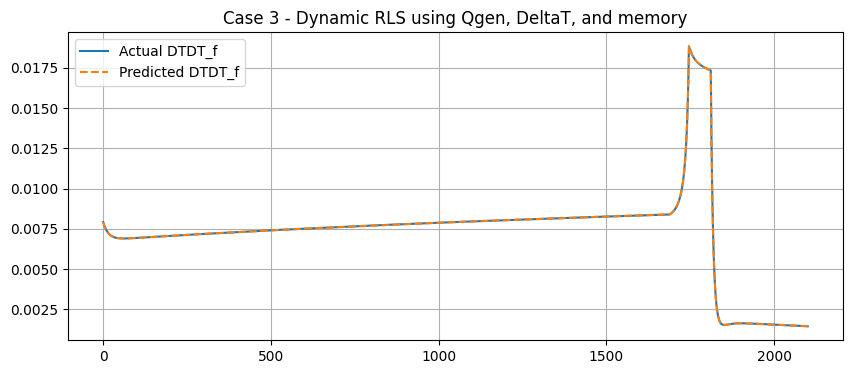

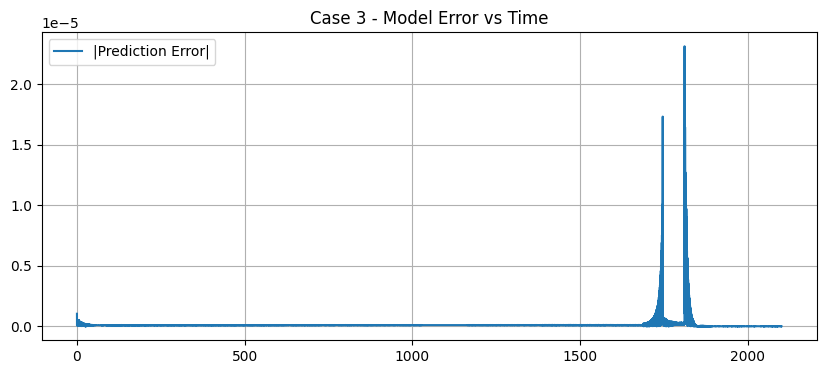

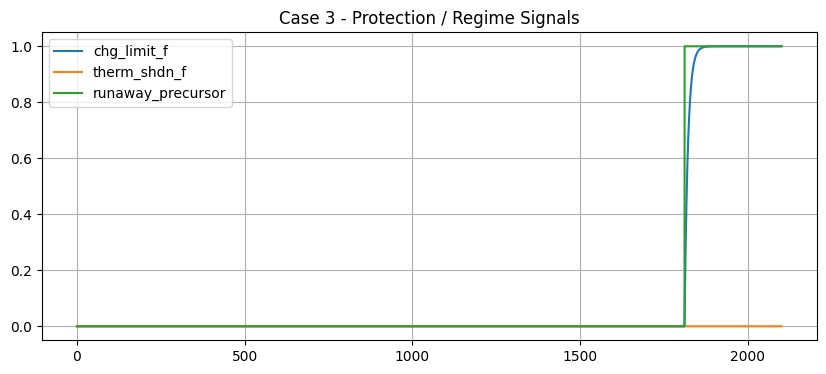

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load Case 3 data
# -------------------------------
file_path = "/kaggle/input/datasets/chaahatsingal/castudythermal/CA3/CA3.txt"
df = pd.read_csv(file_path, sep=r"\s+")

# -------------------------------
# 2. Clean column names
# -------------------------------
df.columns = df.columns.str.replace(r'V\(|\)', '', regex=True)
df.columns = df.columns.str.replace(r'I\(|\)', '', regex=True)

print(df.columns)

# -------------------------------
# 3. Downsample + remove initial transient
# -------------------------------
df_ds = df.iloc[::100].copy()
df_ds = df_ds[df_ds["time"] > 0.01].reset_index(drop=True)

print("Rows before:", len(df))
print("Rows after:", len(df_ds))

# -------------------------------
# 4. Extract signals
# -------------------------------
y = df_ds["dtdt_f"].values
Qgen = df_ds["qgen"].values
DeltaT = df_ds["th_tdelta"].values

chg_limit = df_ds["chg_limit_f"].values if "chg_limit_f" in df_ds.columns else None
therm_shdn = df_ds["therm_shdn_f"].values if "therm_shdn_f" in df_ds.columns else None
precursor = df_ds["runaway_precursor"].values if "runaway_precursor" in df_ds.columns else None

# previous output = memory term
y_prev = np.roll(y, 1)
y_prev[0] = y[0]

# -------------------------------
# 5. Normalize each term safely
# -------------------------------
Qgen_n = Qgen / np.max(np.abs(Qgen)) if np.max(np.abs(Qgen)) != 0 else Qgen
DeltaT_n = DeltaT / np.max(np.abs(DeltaT)) if np.max(np.abs(DeltaT)) != 0 else DeltaT
y_prev_n = y_prev / np.max(np.abs(y_prev)) if np.max(np.abs(y_prev)) != 0 else y_prev

# -------------------------------
# 6. Build dynamic input matrix
# -------------------------------
X = np.vstack([
    y_prev_n,
    Qgen_n,
    DeltaT_n
]).T

print("X shape:", X.shape)
print("y shape:", y.shape)

# -------------------------------
# 7. RLS initialization
# -------------------------------
n = X.shape[1]
theta = np.zeros((n, 1))
P = np.eye(n) * 100
lam = 0.995
theta_history = []

# -------------------------------
# 8. RLS loop
# -------------------------------
for i in range(len(y)):
    x_i = X[i].reshape(-1, 1)
    y_i = y[i]

    denom = lam + (x_i.T @ P @ x_i)[0, 0]
    if abs(denom) < 1e-12:
        continue

    K = (P @ x_i) / denom
    err = y_i - (x_i.T @ theta)[0, 0]
    theta = theta + K * err
    P = (P - K @ x_i.T @ P) / lam
    P = 0.5 * (P + P.T)

    theta_history.append(theta.flatten())

theta_history = np.array(theta_history)

print("Case 3 final estimated parameters:")
print(theta)

# -------------------------------
# 9. Prediction
# -------------------------------
y_pred = (X @ theta).flatten()

# -------------------------------
# 10. Error metrics
# -------------------------------
rmse = np.sqrt(np.mean((y - y_pred)**2))
mae = np.mean(np.abs(y - y_pred))

print("Case 3 RMSE:", rmse)
print("Case 3 MAE:", mae)

# -------------------------------
# 11. Plot actual vs predicted
# -------------------------------
plt.figure(figsize=(10,4))
plt.plot(df_ds["time"], y, label="Actual DTDT_f")
plt.plot(df_ds["time"], y_pred, "--", label="Predicted DTDT_f")
plt.legend()
plt.title("Case 3 - Dynamic RLS using Qgen, DeltaT, and memory")
plt.grid(True)
plt.show()

# -------------------------------
# 12. Plot model error vs time
# -------------------------------
error = np.abs(y - y_pred)

plt.figure(figsize=(10,4))
plt.plot(df_ds["time"], error, label="|Prediction Error|")
plt.legend()
plt.title("Case 3 - Model Error vs Time")
plt.grid(True)
plt.show()

# -------------------------------
# 13. Plot control / protection signals if available
# -------------------------------
plt.figure(figsize=(10,4))
if chg_limit is not None:
    plt.plot(df_ds["time"], chg_limit, label="chg_limit_f")
if therm_shdn is not None:
    plt.plot(df_ds["time"], therm_shdn, label="therm_shdn_f")
if precursor is not None:
    plt.plot(df_ds["time"], precursor, label="runaway_precursor")
plt.legend()
plt.title("Case 3 - Protection / Regime Signals")
plt.grid(True)
plt.show()

Index(['time', 'chg_limit_f', 'dtdt_f', 'nodea', 'qgen', 'qirr', 'qrev',
       'qrxn', 'r0eff', 'runaway_precursor', 'soc', 'tcell_abs', 'th_dcore',
       'th_dsurf', 'th_tcoreabs', 'th_tdelta', 'th_tsurfabs', 'therm_shdn_f',
       'RShunt'],
      dtype='object')
Rows before: 1736233
Rows after: 17361
X shape: (17361, 3)
y shape: (17361,)
Case 5 final estimated parameters:
[[ 0.003781  ]
 [ 0.0572521 ]
 [-0.02759152]]
Case 5 RMSE: 7.02183296226277e-06
Case 5 MAE: 1.6363336406456123e-06


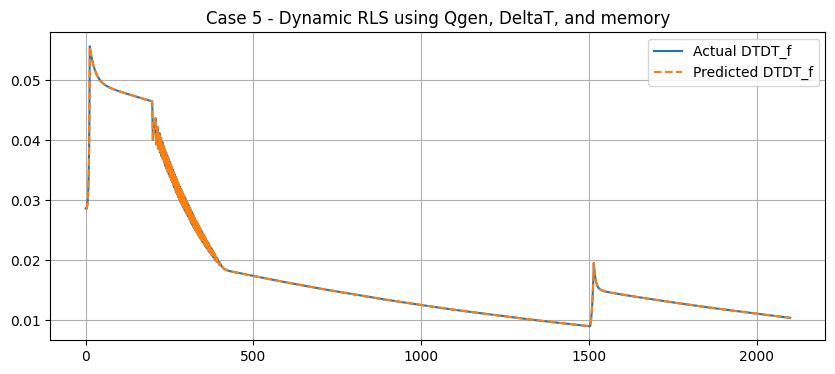

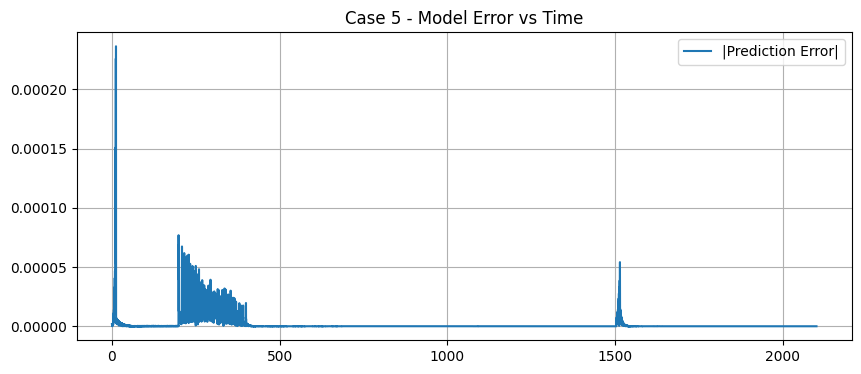

Rolling window: 200
Persistence samples: 5


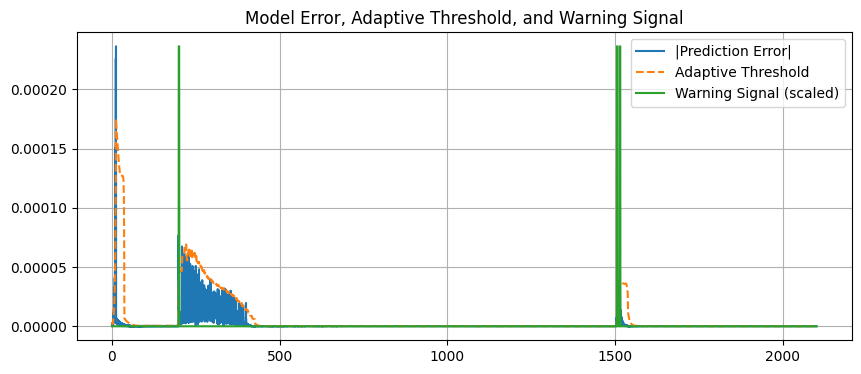

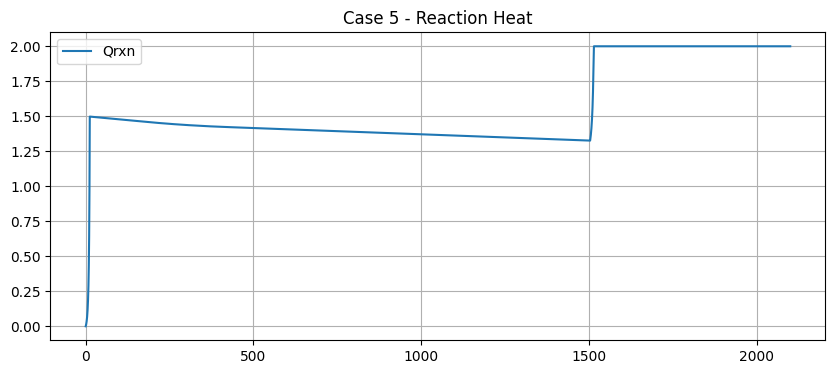

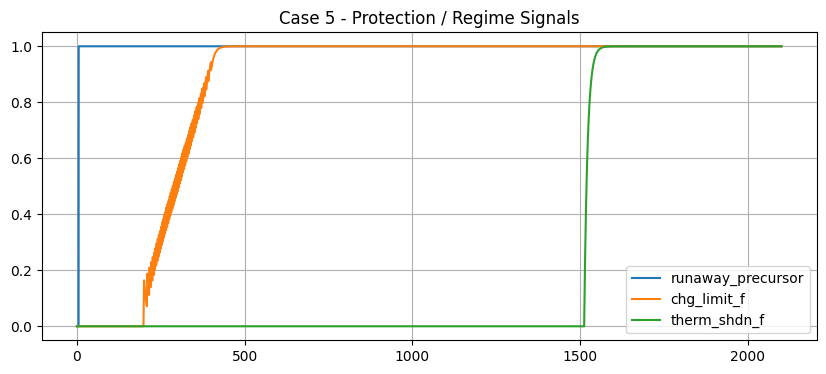

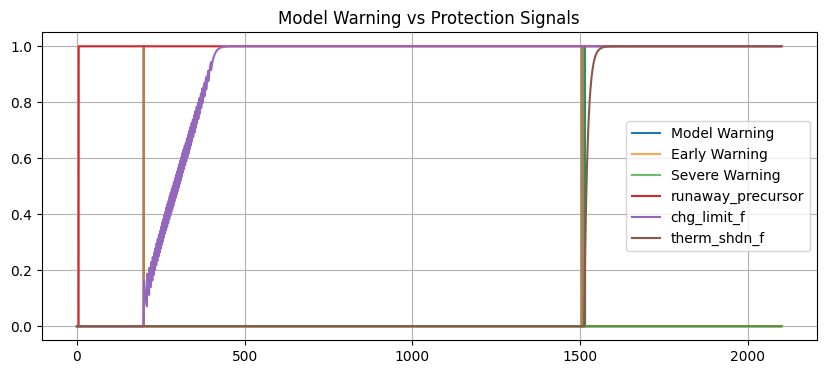

Severe warning time: 1513.960376
Shutdown time: 1685.160376
Lead time: 171.20000000000005


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load Case 5 data
# -------------------------------
file_path = "/kaggle/input/datasets/chaahatsingal/castudythermal/CA5/CA5.txt"
df = pd.read_csv(file_path, sep=r"\s+")

# -------------------------------
# 2. Clean column names
# -------------------------------
df.columns = df.columns.str.replace(r'V\(|\)', '', regex=True)
df.columns = df.columns.str.replace(r'I\(|\)', '', regex=True)

print(df.columns)

# -------------------------------
# 3. Downsample + remove initial transient
# -------------------------------
df_ds = df.iloc[::100].copy()
df_ds = df_ds[df_ds["time"] > 0.01].reset_index(drop=True)

print("Rows before:", len(df))
print("Rows after:", len(df_ds))

# -------------------------------
# 4. Extract signals
# -------------------------------
time = df_ds["time"].values
y = df_ds["dtdt_f"].values
Qgen = df_ds["qgen"].values
DeltaT = df_ds["th_tdelta"].values

Qrxn = df_ds["qrxn"].values if "qrxn" in df_ds.columns else None
chg_limit = df_ds["chg_limit_f"].values if "chg_limit_f" in df_ds.columns else None
therm_shdn = df_ds["therm_shdn_f"].values if "therm_shdn_f" in df_ds.columns else None
precursor = df_ds["runaway_precursor"].values if "runaway_precursor" in df_ds.columns else None

# previous output = memory term
y_prev = np.roll(y, 1)
y_prev[0] = y[0]

# -------------------------------
# 5. Normalize each term safely
# -------------------------------
Qgen_n = Qgen / np.max(np.abs(Qgen)) if np.max(np.abs(Qgen)) != 0 else Qgen
DeltaT_n = DeltaT / np.max(np.abs(DeltaT)) if np.max(np.abs(DeltaT)) != 0 else DeltaT
y_prev_n = y_prev / np.max(np.abs(y_prev)) if np.max(np.abs(y_prev)) != 0 else y_prev

# -------------------------------
# 6. Build dynamic input matrix
# -------------------------------
X = np.vstack([
    y_prev_n,
    Qgen_n,
    DeltaT_n
]).T

print("X shape:", X.shape)
print("y shape:", y.shape)

# -------------------------------
# 7. RLS initialization
# -------------------------------
n = X.shape[1]
theta = np.zeros((n, 1))
P = np.eye(n) * 100
lam = 0.995
theta_history = []

# -------------------------------
# 8. RLS loop
# -------------------------------
for i in range(len(y)):
    x_i = X[i].reshape(-1, 1)
    y_i = y[i]

    denom = lam + (x_i.T @ P @ x_i)[0, 0]
    if abs(denom) < 1e-12:
        continue

    K = (P @ x_i) / denom
    err = y_i - (x_i.T @ theta)[0, 0]
    theta = theta + K * err
    P = (P - K @ x_i.T @ P) / lam
    P = 0.5 * (P + P.T)

    theta_history.append(theta.flatten())

theta_history = np.array(theta_history)

print("Case 5 final estimated parameters:")
print(theta)

# -------------------------------
# 9. Prediction
# -------------------------------
y_pred = (X @ theta).flatten()

# -------------------------------
# 10. Error metrics
# -------------------------------
rmse = np.sqrt(np.mean((y - y_pred)**2))
mae = np.mean(np.abs(y - y_pred))

print("Case 5 RMSE:", rmse)
print("Case 5 MAE:", mae)

# -------------------------------
# 11. Plot actual vs predicted
# -------------------------------
plt.figure(figsize=(10, 4))
plt.plot(time, y, label="Actual DTDT_f")
plt.plot(time, y_pred, "--", label="Predicted DTDT_f")
plt.legend()
plt.title("Case 5 - Dynamic RLS using Qgen, DeltaT, and memory")
plt.grid(True)
plt.show()

# -------------------------------
# 12. Model error
# -------------------------------
error = np.abs(y - y_pred)

plt.figure(figsize=(10, 4))
plt.plot(time, error, label="|Prediction Error|")
plt.legend()
plt.title("Case 5 - Model Error vs Time")
plt.grid(True)
plt.show()

# -------------------------------
# 13. Adaptive threshold
# -------------------------------
err_series = pd.Series(error)

window = 200
rolling_mean = err_series.rolling(window=window, min_periods=1).mean()
rolling_std = err_series.rolling(window=window, min_periods=1).std().fillna(0)

threshold = (rolling_mean + 3 * rolling_std).values

print("Rolling window:", window)

# -------------------------------
# 14. Early warning logic
# -------------------------------
warning_raw = (error > threshold).astype(int)

persist_N = 5
warning_early = np.zeros_like(warning_raw)

count = 0
for i in range(len(warning_raw)):
    if warning_raw[i] == 1:
        count += 1
    else:
        count = 0

    if count >= persist_N:
        warning_early[i] = 1

print("Persistence samples:", persist_N)

# -------------------------------
# 15. Severe warning logic
# -------------------------------
error_diff = np.diff(error, prepend=error[0])
spike_threshold = 3 * np.std(error_diff)

if Qrxn is not None:
    late_region = Qrxn > 1.8
else:
    late_region = time > 1000

warning_severe = ((error_diff > spike_threshold) & late_region).astype(int)

# -------------------------------
# 16. Final combined warning
# -------------------------------
warning_final = np.logical_or(warning_early, warning_severe).astype(int)
warning_display = pd.Series(warning_final).rolling(window=10, min_periods=1).max().values

# -------------------------------
# 17. Plot error + threshold + warning
# -------------------------------
plt.figure(figsize=(10, 4))
plt.plot(time, error, label="|Prediction Error|")
plt.plot(time, threshold, "--", label="Adaptive Threshold")
plt.plot(time, warning_display * np.max(error), label="Warning Signal (scaled)")
plt.legend()
plt.title("Model Error, Adaptive Threshold, and Warning Signal")
plt.grid(True)
plt.show()

# -------------------------------
# 18. Plot Qrxn if available
# -------------------------------
if Qrxn is not None:
    plt.figure(figsize=(10, 4))
    plt.plot(time, Qrxn, label="Qrxn")
    plt.legend()
    plt.title("Case 5 - Reaction Heat")
    plt.grid(True)
    plt.show()

# -------------------------------
# 19. Plot protection / regime signals
# -------------------------------
plt.figure(figsize=(10, 4))
if precursor is not None:
    plt.plot(time, precursor, label="runaway_precursor")
if chg_limit is not None:
    plt.plot(time, chg_limit, label="chg_limit_f")
if therm_shdn is not None:
    plt.plot(time, therm_shdn, label="therm_shdn_f")
plt.legend()
plt.title("Case 5 - Protection / Regime Signals")
plt.grid(True)
plt.show()

# -------------------------------
# 20. Plot warning vs protection signals
# -------------------------------
plt.figure(figsize=(10, 4))
plt.plot(time, warning_final, label="Model Warning")
plt.plot(time, warning_early, label="Early Warning", alpha=0.7)
plt.plot(time, warning_severe, label="Severe Warning", alpha=0.7)

if precursor is not None:
    plt.plot(time, precursor, label="runaway_precursor")
if chg_limit is not None:
    plt.plot(time, chg_limit, label="chg_limit_f")
if therm_shdn is not None:
    plt.plot(time, therm_shdn, label="therm_shdn_f")

plt.legend()
plt.title("Model Warning vs Protection Signals")
plt.grid(True)
plt.show()

# -------------------------------
# 21. Lead time using severe warning
# -------------------------------
warning_idx = np.where(warning_severe == 1)[0]
shdn_idx = np.where(therm_shdn == 1)[0] if therm_shdn is not None else []

if len(warning_idx) > 0 and len(shdn_idx) > 0:
    t_warning = time[warning_idx[0]]
    t_shutdown = time[shdn_idx[0]]
    lead_time = t_shutdown - t_warning

    print("Severe warning time:", t_warning)
    print("Shutdown time:", t_shutdown)
    print("Lead time:", lead_time)
else:
    print("Lead time could not be computed.")